In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [2]:
# 1. Generate Synthetic 1D Data (p=1)
np.random.seed(42)
# Class 0: Mean=2, Std=1
class_0 = np.random.normal(2, 1, 100)
# Class 1: Mean=5, Std=1 (Shared variance!)
class_1 = np.random.normal(5, 1, 100)

In [3]:
X = np.concatenate([class_0, class_1]).reshape(-1, 1)
y = np.concatenate([np.zeros(100), np.ones(100)])


In [ ]:
# 2. Fit the LDA Model
lda = LinearDiscriminantAnalysis()
lda.fit(X, y)


,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [5]:
# 3. Predict and Find the Boundary
# The boundary is where the probability for both classes is 0.5
x_range = np.linspace(-2, 9, 1000).reshape(-1, 1)
probs = lda.predict_proba(x_range)
boundary_x = x_range[np.abs(probs[:, 0] - 0.5).argmin()]



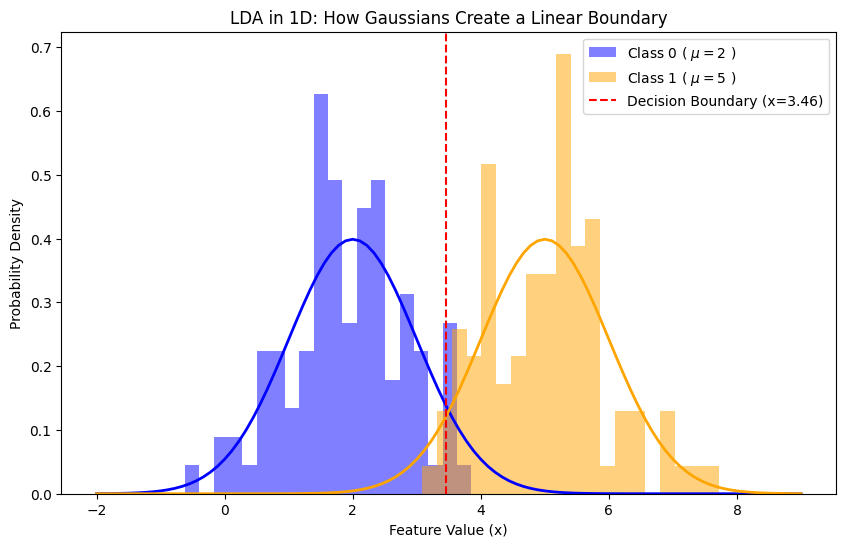

In [9]:
# 4. Visualization
plt.figure(figsize=(10, 6))

# Plot the histograms (the actual data)
plt.hist(class_0, bins=20, alpha=0.5, label='Class 0 ( $\mu=2$ )', color='blue', density=True)
plt.hist(class_1, bins=20, alpha=0.5, label='Class 1 ( $\mu=5$ )', color='orange', density=True)

# Plot the theoretical Gaussian PDF curves
from scipy.stats import norm
x_axis = np.linspace(-2, 9, 100)
plt.plot(x_axis, norm.pdf(x_axis, 2, 1), color='blue', lw=2)
plt.plot(x_axis, norm.pdf(x_axis, 5, 1), color='orange', lw=2)

# Draw the Decision Boundary
plt.axvline(boundary_x, color='red', linestyle='--', label=f'Decision Boundary (x={boundary_x[0]:.2f})')
plt.title("LDA in 1D: How Gaussians Create a Linear Boundary")
plt.xlabel("Feature Value (x)")
plt.ylabel("Probability Density")
plt.legend()
plt.show()